# 07 - Particles that enter the retroflection and then sink

The runs are 3D (`AdvectionRK4_3D`), so every trajectory carries a depth `z`
(`positive: down`, metres). Particles are released in the top few metres
(median 3.5 m) and most stay shallow, but a minority subduct.

This notebook finds the ones that **enter the retroflection box first and sink
afterwards** - the order matters, so the depth test only looks at the part of
the path *after* the first box entry. It counts them, then animates 20 of them
as a GIF.

Nothing here depends on the k-means labels; the qualifying trajectory ids are
saved so they can be cross-referenced with clusters later.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from joblib import Parallel, delayed
import config as C

# --- TUNE ME -----------------------------------------------------------------
RETRO_LAT  = (5.0, 8.0)        # retroflection box, degrees N
RETRO_LON  = (-48.0, -44.0)    # ... degrees E (negative = W)
SINK_DEPTH = 100.0             # m; "sank" = deeper than this AFTER entering
N_SHOW     = 20                # trajectories in the GIF
GIF_STEP   = 2                 # days per frame
GIF_FPS    = 12
# -----------------------------------------------------------------------------

N_IO_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", 16))
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "0.88"

def style(ax, xlab="", ylab=""):
    ax.set_xlabel(xlab, fontsize=9, color=MUTED)
    ax.set_ylabel(ylab, fontsize=9, color=MUTED)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("0.8")
    ax.tick_params(colors=MUTED, labelsize=8, length=0)
    ax.set_axisbelow(True)
    return ax

stores = C.list_stores()
print(f"{len(stores)} stores | retroflection box lat {RETRO_LAT} lon {RETRO_LON}"
      f" | sink deeper than {SINK_DEPTH} m")

1528 stores | retroflection box lat (5.0, 8.0) lon (-48.0, -44.0) | sink deeper than 100.0 m


## Scan every store
For each particle: find the first observation inside the box, then take the
**maximum depth reached from that observation onward**. A particle qualifies if
that maximum exceeds `SINK_DEPTH`. Recording the entry day and the sink day
lets us see how long the subduction takes.

~1 s per store, so a few minutes threaded over the full archive.

In [2]:
def _scan(path):
    ds = xr.open_zarr(path)
    lat, lon, z = ds.lat.values, ds.lon.values, ds.z.values
    time = ds.time.values
    rel = (time - time[:, :1]) / np.timedelta64(1, "D")

    inbox = ((lat > RETRO_LAT[0]) & (lat < RETRO_LAT[1])
             & (lon > RETRO_LON[0]) & (lon < RETRO_LON[1]))
    hit = inbox.any(axis=1)
    if not hit.any():
        return None
    idx = np.where(hit)[0]
    first = inbox[idx].argmax(axis=1)                 # first obs inside the box

    rows = []
    for i, f in zip(idx, first):
        zz = z[i, f:]
        if np.all(np.isnan(zz)):
            continue
        deep = np.nanmax(zz)
        if deep <= SINK_DEPTH:
            continue
        j = f + int(np.nanargmax(zz > SINK_DEPTH))    # first crossing after entry
        rows.append((int(i), float(rel[i, f]), float(rel[i, j]),
                     float(deep), float(lat[i, j]), float(lon[i, j])))
    if not rows:
        return None
    out = pd.DataFrame(rows, columns=["local", "entry_day", "sink_day",
                                      "max_depth_after", "sink_lat", "sink_lon"])
    out["store"] = path.stem
    out["n_inbox"] = int(hit.sum())
    return out

res = Parallel(n_jobs=N_IO_THREADS, backend="threading", verbose=1)(
    delayed(_scan)(p) for p in stores)
sink = pd.concat([r for r in res if r is not None], ignore_index=True)
print(f"\nqualifying particles: {len(sink):,}")

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    5.8s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:   21.7s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:   49.9s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:  1.5min
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:  2.3min



qualifying particles: 2,421


[Parallel(n_jobs=16)]: Done 1528 out of 1528 | elapsed:  2.9min finished


## How many are they?

In [3]:
n_tot = len(stores) * C.TRAJ_PER_STORE
n_inbox = sink.groupby("store").n_inbox.first().sum()
print(f"released total          : {n_tot:,}")
print(f"entered the box         : {n_inbox:,}   ({100*n_inbox/n_tot:.3f}%)")
print(f"  ... and then sank     : {len(sink):,}   ({100*len(sink)/n_tot:.4f}% of all,"
      f" {100*len(sink)/n_inbox:.1f}% of those that entered)")

sink["release_time"] = pd.to_datetime(
    sink.store.str.extract(r"_(\d{4}-\d{2}-\d{2})", expand=False))
sink["year"]  = sink.release_time.dt.year
sink["month"] = sink.release_time.dt.month
sink["lag"]   = sink.sink_day - sink.entry_day       # days from entry to sinking

print("\nsubduction depth / timing:")
print(sink[["entry_day", "sink_day", "lag", "max_depth_after"]]
      .describe().round(1).to_string())

released total          : 15,280,000
entered the box         : 239,606   (1.568%)
  ... and then sank     : 2,421   (0.0158% of all, 1.0% of those that entered)

subduction depth / timing:
       entry_day  sink_day     lag  max_depth_after
count     2421.0    2421.0  2421.0           2421.0
mean        72.6     140.1    67.6            122.8
std         38.0      31.1    41.2             26.6
min         24.8      43.8     0.0            100.0
25%         43.8     113.5    30.0            105.0
50%         61.8     145.2    72.0            115.1
75%         91.0     166.8   101.5            130.9
max        184.5     184.8   159.8            397.5


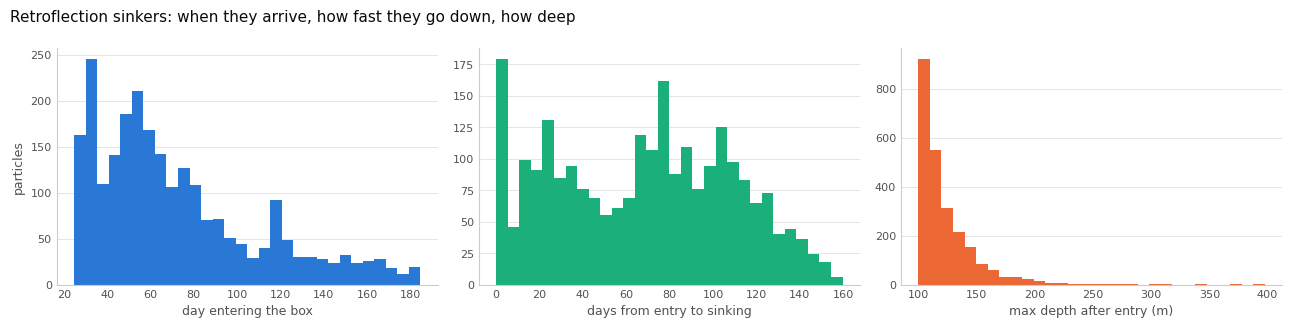

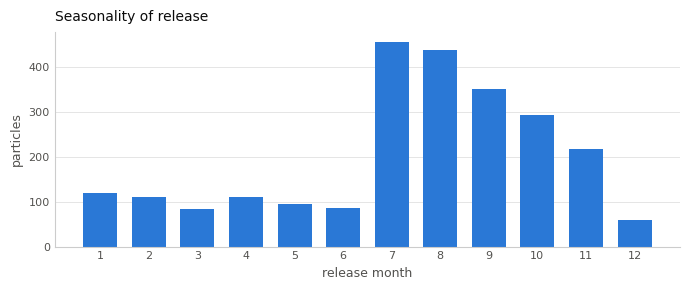

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
axes[0].hist(sink.entry_day, bins=30, color=BLUE)
style(axes[0], "day entering the box", "particles")
axes[1].hist(sink.lag, bins=30, color=AQUA)
style(axes[1], "days from entry to sinking", "")
axes[2].hist(sink.max_depth_after, bins=30, color=ORANGE)
style(axes[2], "max depth after entry (m)", "")
for a in axes:
    a.yaxis.grid(True, color=GRID, lw=.6)
fig.suptitle("Retroflection sinkers: when they arrive, how fast they go down, how deep",
             fontsize=11, color=INK, x=.01, ha="left")
fig.tight_layout(); plt.show()

by_m = sink.groupby("month").size()
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(by_m.index, by_m.values, color=BLUE, width=.7)
ax.set_xticks(range(1, 13))
ax.yaxis.grid(True, color=GRID, lw=.6)
style(ax, "release month", "particles")
ax.set_title("Seasonality of release", fontsize=10, color=INK, pad=8, loc="left")
fig.tight_layout(); plt.show()

## Pick 20 and stream their full paths
Sampled across the whole archive - date does not matter here. Each path is
interpolated onto a common day grid so they can share one animation clock.

In [5]:
pick = sink.sample(n=min(N_SHOW, len(sink)), random_state=C.RANDOM_STATE)
store_paths = {p.stem: p for p in stores}
GRID_DAYS = np.arange(0, 181, GIF_STEP)

def _path(name, grp):
    ds = xr.open_zarr(store_paths[name])
    loc = grp.local.to_numpy()
    lat, lon, z = ds.lat.values[loc], ds.lon.values[loc], ds.z.values[loc]
    t = ds.time.values[loc]
    rel = (t - t[:, :1]) / np.timedelta64(1, "D")
    out = []
    for k in range(len(loc)):
        ok = ~np.isnan(lon[k]) & ~np.isnat(t[k])
        if ok.sum() < 2:
            continue
        out.append(dict(
            store=name, local=int(loc[k]),
            lat=np.interp(GRID_DAYS, rel[k][ok], lat[k][ok], left=np.nan, right=np.nan),
            lon=np.interp(GRID_DAYS, rel[k][ok], lon[k][ok], left=np.nan, right=np.nan),
            z=np.interp(GRID_DAYS, rel[k][ok], z[k][ok], left=np.nan, right=np.nan),
            last_day=float(rel[k][ok].max())))
    return out

tracks = [t for name, grp in pick.groupby("store") for t in _path(name, grp)]
for t in tracks:                       # blank the grid past each particle's end
    dead = GRID_DAYS > t["last_day"]
    t["lat"][dead] = np.nan; t["lon"][dead] = np.nan; t["z"][dead] = np.nan
print(f"streamed {len(tracks)} trajectories on a {len(GRID_DAYS)}-frame clock "
      f"(0..180 d, step {GIF_STEP})")

streamed 20 trajectories on a 91-frame clock (0..180 d, step 2)


## Static overview
All 20 at once, coloured by depth, with the retroflection box in green. This is
the still version of the animation below.

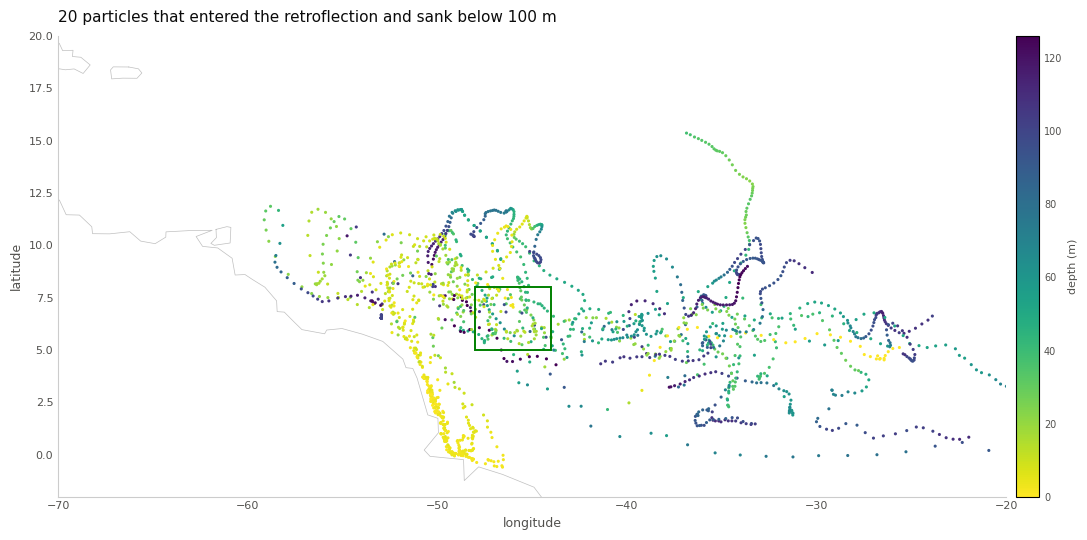

In [6]:
import cartopy.feature as cfeature
_coast = []
for geom in cfeature.COASTLINE.with_scale("110m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        _coast.append((np.asarray(line.xy[0]), np.asarray(line.xy[1])))

LON_LIM = (-70, -20)
LAT_LIM = (-2, 20)

def draw_base(ax):
    for x, y in _coast:
        ax.plot(x, y, "-", color="0.75", lw=.5, zorder=1)
    ax.add_patch(plt.Rectangle(
        (RETRO_LON[0], RETRO_LAT[0]), RETRO_LON[1] - RETRO_LON[0],
        RETRO_LAT[1] - RETRO_LAT[0], fill=False, ec="green", lw=1.4, zorder=5))
    ax.set_xlim(*LON_LIM); ax.set_ylim(*LAT_LIM)
    style(ax, "longitude", "latitude")

fig, ax = plt.subplots(figsize=(11, 5.5))
draw_base(ax)
allz = np.concatenate([t["z"] for t in tracks])
vmax = float(np.nanpercentile(allz, 99))
for t in tracks:
    sc = ax.scatter(t["lon"], t["lat"], c=t["z"], cmap="viridis_r", s=5,
                    vmin=0, vmax=vmax, zorder=3, linewidths=0)
cb = fig.colorbar(sc, ax=ax, pad=.01, fraction=.03)
cb.set_label("depth (m)", fontsize=8, color=MUTED)
cb.ax.tick_params(colors=MUTED, labelsize=7, length=0)
ax.set_title(f"{len(tracks)} particles that entered the retroflection and sank "
             f"below {SINK_DEPTH:.0f} m", fontsize=11, color=INK, pad=10, loc="left")
fig.tight_layout(); plt.show()

## The GIF
Two panels sharing one clock: the map on top, depth-against-time below. Each
particle keeps a fading tail so the path is readable while it moves. Dots turn
dark as they subduct.

wrote retroflection_sinkers_100m.gif  (1.3 MB, 91 frames)


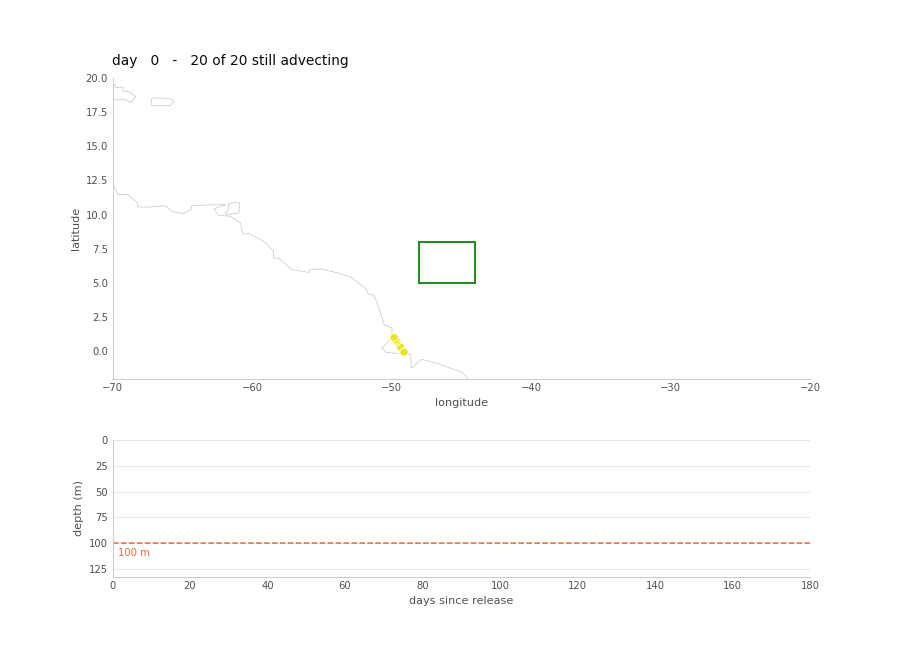

In [7]:
GIF = f"retroflection_sinkers_{int(SINK_DEPTH)}m.gif"
TAIL = 20                                    # frames of visible tail

fig, (axm, axz) = plt.subplots(
    2, 1, figsize=(10, 7.2), height_ratios=[2.2, 1],
    gridspec_kw=dict(hspace=.28))
draw_base(axm)
axz.set_xlim(0, GRID_DAYS[-1]); axz.set_ylim(vmax * 1.05, 0)
axz.axhline(SINK_DEPTH, color=ORANGE, lw=1.2, ls="--", zorder=2)
axz.annotate(f"{SINK_DEPTH:.0f} m", (0, SINK_DEPTH), xytext=(4, -4),
             textcoords="offset points", fontsize=8, color=ORANGE, va="top")
axz.yaxis.grid(True, color=GRID, lw=.6)
style(axz, "days since release", "depth (m)")

cmap = plt.get_cmap("viridis_r")
tails  = [axm.plot([], [], "-", lw=1.0, color="0.6", alpha=.6, zorder=2)[0] for _ in tracks]
heads  = axm.scatter([], [], s=44, c=[], cmap="viridis_r", vmin=0, vmax=vmax,
                     ec="white", linewidths=.7, zorder=6)
zlines = [axz.plot([], [], "-", lw=1.0, color=BLUE, alpha=.55)[0] for _ in tracks]
title  = axm.set_title("", fontsize=11, color=INK, pad=10, loc="left")

def _frame(f):
    lo = max(0, f - TAIL)
    xy, cs = [], []
    for k, t in enumerate(tracks):
        tails[k].set_data(t["lon"][lo:f + 1], t["lat"][lo:f + 1])
        zlines[k].set_data(GRID_DAYS[:f + 1], t["z"][:f + 1])
        if not np.isnan(t["lon"][f]):
            xy.append((t["lon"][f], t["lat"][f])); cs.append(t["z"][f])
    heads.set_offsets(np.array(xy).reshape(-1, 2))
    heads.set_array(np.array(cs))
    alive = len(xy)
    title.set_text(f"day {GRID_DAYS[f]:3d}   -   {alive} of {len(tracks)} still advecting")
    return tails + zlines + [heads, title]

anim = animation.FuncAnimation(fig, _frame, frames=len(GRID_DAYS), blit=False)
anim.save(GIF, writer=animation.PillowWriter(fps=GIF_FPS), dpi=90)
plt.close(fig)
print(f"wrote {GIF}  ({os.path.getsize(GIF)/1e6:.1f} MB, {len(GRID_DAYS)} frames)")

from IPython.display import Image, display
display(Image(filename=GIF))

## Save the qualifying ids
`trajectory_id` is rebuilt from the store's position in `list_stores()`, the
same convention as notebook 01 - so these join straight onto
`labeled_trajectories.parquet` once notebook 03 has run.

In [9]:
store_index = {p.stem: i for i, p in enumerate(stores)}
sink["trajectory_id"] = (sink.store.map(store_index) * C.TRAJ_PER_STORE
                         + sink.local).astype(np.int64)
OUT = C.DATA_DIR / f"retroflection_sinkers_{int(SINK_DEPTH)}m.parquet"
sink.to_parquet(OUT, index=False)
print("saved", sink.shape, "->", OUT)
print("\ncolumns:", list(sink.columns))
sink

saved (2421, 13) -> /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_30_180_stdZ_w/data/retroflection_sinkers_100m.parquet

columns: ['local', 'entry_day', 'sink_day', 'max_depth_after', 'sink_lat', 'sink_lon', 'store', 'n_inbox', 'release_time', 'year', 'month', 'lag', 'trajectory_id']


,local,entry_day,sink_day,max_depth_after,sink_lat,sink_lon,store,n_inbox,release_time,year,month,lag,trajectory_id
0,1242,84.25,169.50,126.938086,8.060658,-46.117624,Parcels_run_45678_1993-01-06 00:00:00,42,1993-01-06,1993,1,85.25,1242
1,3751,74.75,156.00,107.279045,3.565967,-44.320947,Parcels_run_45678_1993-01-06 00:00:00,42,1993-01-06,1993,1,81.25,3751
2,4830,70.25,157.50,103.476734,3.723787,-44.273189,Parcels_run_45678_1993-01-06 00:00:00,42,1993-01-06,1993,1,87.25,4830
3,6196,79.25,176.50,137.485823,4.386170,-46.103117,Parcels_run_45678_1993-01-06 00:00:00,42,1993-01-06,1993,1,97.25,6196
4,8093,77.50,169.50,104.460035,6.170061,-45.191896,Parcels_run_45678_1993-01-06 00:00:00,42,1993-01-06,1993,1,92.00,8093
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2416,9351,119.50,146.75,109.872469,7.760766,-42.056383,Parcels_run_78876_2013-11-18 00:00:00,70,2013-11-18,2013,11,27.25,15199351
2417,9437,118.75,152.75,105.117732,7.312194,-41.359094,Parcels_run_78876_2013-11-18 00:00:00,70,2013-11-18,2013,11,34.00,15199437
2418,2427,103.75,174.25,118.991192,4.228344,-44.332263,Parcels_run_78876_2013-12-03 00:00:00,3,2013-12-03,2013,12,70.50,15222427
2419,2562,77.75,141.25,109.471008,6.749490,-38.692746,Parcels_run_78876_2013-12-03 00:00:00,3,2013-12-03,2013,12,63.50,15222562


## 3D animation of the sinking, coloured by density
The `N_SHOW` sample above is representative, not extreme, so this re-selects:
take the `DEEP_N` deepest sinkers and, among those, the two that travel closest
together - the pair is both **deep** and matched, which makes the descent
legible instead of two unrelated squiggles.

Longitude x latitude x depth, animated in time with a slow orbit. **The whole
trail is coloured by `sigma0`**, not just the leading tip, so the density
history of the path stays on screen; the two particles are told apart by marker
shape (circle / square) since colour is spoken for. `plasma_r` puts light water
at yellow and dense water at purple.

`sigma0` follows the same TEOS-10 recipe as
`particle_diagnostics/0.Mechanism_Diagnostics` (pressure from depth, practical
-> absolute salinity, potential -> conservative temperature), evaluated on the
native observations and only then interpolated, so the equation of state never
sees interpolated T/S.

Yellow staying yellow as the depth grows would mean adiabatic subduction along
an isopycnal; yellow turning purple means the water is being transformed.


deepest 60: 192..398 m
chosen pair: mean separation 0.71 deg
  Parcels_run_45678_1995-07-06 00:00:00  local=3932  max depth 224 m  sigma0 4.48 -> 26.73 kg/m3
  Parcels_run_45678_1995-07-06 00:00:00  local=3351  max depth 207 m  sigma0 6.42 -> 26.67 kg/m3

wrote retroflection_sink_3d_200m.gif  (3.1 MB, 91 frames)  |  sigma0 4.2..26.7 kg/m3


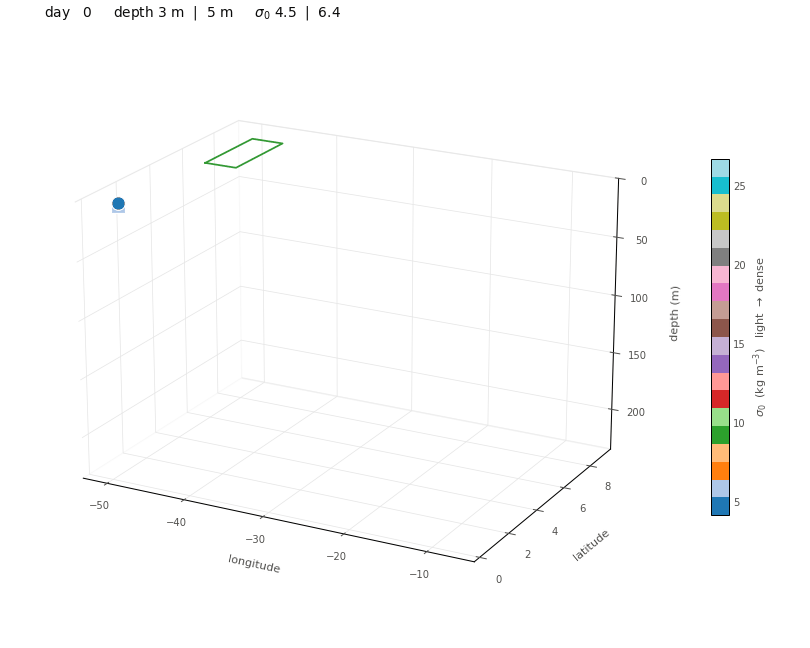

In [13]:
import gsw                                        # TEOS-10
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401  (registers 3d)
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- TUNE ME -----------------------------------------------------------------
DEEP_N         = 60      # consider this many of the deepest sinkers
PAIR_MIN_DEPTH = 200.0   # both members of the pair must pass this depth (m)
SIGMA_CMAP     = "tab20"   # light water -> yellow, dense -> purple
# -----------------------------------------------------------------------------

def _path_sigma(name, grp):
    """Same as `_path` but also carries sigma0 (potential density anomaly).

    Recipe follows particle_diagnostics/0.Mechanism_Diagnostics: pressure from
    depth, practical -> absolute salinity, potential -> conservative temperature,
    then sigma0. Computed on the NATIVE observations and interpolated afterwards,
    so the equation of state never sees interpolated T/S.
    """
    ds = xr.open_zarr(store_paths[name])
    loc = grp.local.to_numpy()
    lat, lon, z = ds.lat.values[loc], ds.lon.values[loc], ds.z.values[loc]
    sal, temp = ds.sal.values[loc], ds.temp.values[loc]
    t = ds.time.values[loc]
    rel = (t - t[:, :1]) / np.timedelta64(1, "D")

    p  = gsw.p_from_z(-z, lat)                  # z is positive down -> height = -z
    SA = gsw.SA_from_SP(sal, p, lon, lat)
    CT = gsw.CT_from_pt(SA, temp)
    s0 = gsw.sigma0(SA, CT)

    out = []
    for k in range(len(loc)):
        ok = ~np.isnan(lon[k]) & ~np.isnat(t[k])
        if ok.sum() < 2:
            continue
        d = dict(store=name, local=int(loc[k]), last_day=float(rel[k][ok].max()))
        for nm, arr in (("lat", lat), ("lon", lon), ("z", z), ("sigma0", s0)):
            d[nm] = np.interp(GRID_DAYS, rel[k][ok], arr[k][ok],
                              left=np.nan, right=np.nan)
        out.append(d)
    return out

# The N_SHOW sample above is representative, not extreme, so re-select here:
# take the deepest sinkers and, among those, the two that travel together.
deep = sink.nlargest(DEEP_N, "max_depth_after")
dtracks = [t for name, grp in deep.groupby("store") for t in _path_sigma(name, grp)]
for t in dtracks:
    dead = GRID_DAYS > t["last_day"]
    for nm in ("lat", "lon", "z", "sigma0"):
        t[nm][dead] = np.nan

best, pair = np.inf, None
for i in range(len(dtracks)):
    for j in range(i + 1, len(dtracks)):
        a, b = dtracks[i], dtracks[j]
        if min(np.nanmax(a["z"]), np.nanmax(b["z"])) < PAIR_MIN_DEPTH:
            continue
        m = ~np.isnan(a["lon"]) & ~np.isnan(b["lon"])
        if m.sum() < len(GRID_DAYS) * 0.6:          # need real overlap in time
            continue
        d = float(np.mean(np.hypot(a["lon"][m] - b["lon"][m],
                                   a["lat"][m] - b["lat"][m])))
        if d < best:
            best, pair = d, (i, j)

duo = [dtracks[k] for k in pair]
print(f"deepest {DEEP_N}: {deep.max_depth_after.min():.0f}..{deep.max_depth_after.max():.0f} m")
print(f"chosen pair: mean separation {best:.2f} deg")
for t in duo:
    s = t["sigma0"][np.isfinite(t["sigma0"])]
    print(f"  {t['store']}  local={t['local']}  max depth {np.nanmax(t['z']):.0f} m"
          f"  sigma0 {s[0]:.2f} -> {s[-1]:.2f} kg/m3")

# --- 3D animation: lon x lat x depth, particle coloured by sigma0 ------------
GIF3D = f"retroflection_sink_3d_{int(PAIR_MIN_DEPTH)}m.gif"
lons = np.concatenate([t["lon"] for t in duo])
lats = np.concatenate([t["lat"] for t in duo])
zs   = np.concatenate([t["z"]   for t in duo])
sg   = np.concatenate([t["sigma0"] for t in duo])
XL = (np.nanmin(lons) - .8, np.nanmax(lons) + .8)
YL = (np.nanmin(lats) - .8, np.nanmax(lats) + .8)
ZL = float(np.nanmax(zs)) * 1.05
SMIN, SMAX = float(np.nanmin(sg)), float(np.nanmax(sg))

fig = plt.figure(figsize=(9, 7.2))
ax = fig.add_subplot(111, projection="3d")
fig.subplots_adjust(left=.02, right=.90, bottom=.02, top=.94)   # fill the canvas
ax.set_box_aspect((1.5, 1.1, 1.0))                              # widen the map plane
ax.set_xlim(*XL); ax.set_ylim(*YL); ax.set_zlim(ZL, 0)          # depth increases down
ax.set_xlabel("longitude", fontsize=9, color=MUTED, labelpad=8)
ax.set_ylabel("latitude", fontsize=9, color=MUTED, labelpad=8)
ax.set_zlabel("depth (m)", fontsize=9, color=MUTED, labelpad=8)
ax.tick_params(colors=MUTED, labelsize=8)
for a in (ax.xaxis, ax.yaxis, ax.zaxis):
    a._axinfo["grid"].update(color="0.9", linewidth=.6)
    a.pane.set_facecolor("white"); a.pane.set_alpha(.6)

# retroflection box on the surface plane
bx = [RETRO_LON[0], RETRO_LON[1], RETRO_LON[1], RETRO_LON[0], RETRO_LON[0]]
by = [RETRO_LAT[0], RETRO_LAT[0], RETRO_LAT[1], RETRO_LAT[1], RETRO_LAT[0]]
ax.plot(bx, by, zs=0, zdir="z", color="green", lw=1.4, alpha=.8)

NORM = Normalize(SMIN, SMAX)

# Pre-build one coloured segment set per particle: the TRAIL carries sigma0, so
# the whole path shows the density transformation, not just the current tip.
segsets = []
for t in duo:
    pts = np.column_stack([t["lon"], t["lat"], t["z"]])
    seg = np.stack([pts[:-1], pts[1:]], axis=1)            # (n-1, 2, 3)
    cval = 0.5 * (t["sigma0"][:-1] + t["sigma0"][1:])      # colour per segment
    good = np.isfinite(seg).all(axis=(1, 2)) & np.isfinite(cval)
    segsets.append((seg, cval, good))

# identity is carried by marker shape now that colour is spoken for
MARKERS = ["o", "s"]
lines = []
for seg, cval, good in segsets:
    # seed with one real segment: add_collection3d cannot autoscale an empty one
    lc = Line3DCollection(seg[good][:1], cmap=SIGMA_CMAP, norm=NORM, linewidths=2.4)
    try:
        ax.add_collection3d(lc, autolim=False)
    except TypeError:                       # older matplotlib
        ax.add_collection3d(lc)
    lines.append(lc)
ax.set_xlim(*XL); ax.set_ylim(*YL); ax.set_zlim(ZL, 0)   # re-assert after autolim
shadows = [ax.plot([], [], [], "-", lw=1.0, color="0.8", alpha=.75)[0] for _ in duo]
drops   = [ax.plot([], [], [], "-", lw=.9, color="0.55", alpha=.45)[0] for _ in duo]
heads   = [ax.scatter([t["lon"][0]], [t["lat"][0]], [t["z"][0]], s=120,
                      c=[t["sigma0"][0]], cmap=SIGMA_CMAP, norm=NORM,
                      marker=m, ec="white", linewidths=1.0,
                      depthshade=False, zorder=6)
           for t, m in zip(duo, MARKERS)]

cb = fig.colorbar(ScalarMappable(norm=NORM, cmap=SIGMA_CMAP), ax=ax,
                  pad=.10, fraction=.025, shrink=.62)
cb.set_label(r"$\sigma_0$  (kg m$^{-3}$)   light $\rightarrow$ dense",
             fontsize=9, color=MUTED)
cb.ax.tick_params(colors=MUTED, labelsize=8, length=0)

def _frame3d(f):
    for k, t in enumerate(duo):
        seg, cval, good = segsets[k]
        keep = good & (np.arange(len(seg)) < max(f, 1))
        lines[k].set_segments(seg[keep])
        lines[k].set_array(cval[keep])
        x, y = t["lon"][:f + 1], t["lat"][:f + 1]
        shadows[k].set_data(x, y); shadows[k].set_3d_properties(np.zeros_like(x))
        if not np.isnan(t["lon"][f]):
            xx, yy, zv = t["lon"][f], t["lat"][f], t["z"][f]
            heads[k]._offsets3d = (np.array([xx]), np.array([yy]), np.array([zv]))
            heads[k].set_array(np.array([t["sigma0"][f]]))
            drops[k].set_data([xx, xx], [yy, yy])
            drops[k].set_3d_properties([0, zv])
    dep = "  |  ".join(f"{np.nan_to_num(t['z'][f]):.0f} m" for t in duo)
    sig = "  |  ".join(f"{np.nan_to_num(t['sigma0'][f]):.1f}" for t in duo)
    ax.set_title(f"day {GRID_DAYS[f]:3d}     depth {dep}     "
                 r"$\sigma_0$ " + sig,
                 fontsize=11, color=INK, pad=18, loc="left")
    ax.view_init(elev=20, azim=-62 + 0.30 * f)              # slow orbit
    return lines + shadows + drops + heads

anim3d = animation.FuncAnimation(fig, _frame3d, frames=len(GRID_DAYS), blit=False)
anim3d.save(GIF3D, writer=animation.PillowWriter(fps=GIF_FPS), dpi=90)
plt.close(fig)
print(f"\nwrote {GIF3D}  ({os.path.getsize(GIF3D)/1e6:.1f} MB, {len(GRID_DAYS)} frames)"
      f"  |  sigma0 {SMIN:.1f}..{SMAX:.1f} kg/m3")

from IPython.display import Image, display
display(Image(filename=GIF3D))


## Interactive version - drag to rotate
The same pair and the same `sigma0` colouring as the GIF above, but static in
time and **interactive in space**: drag to orbit, scroll to zoom, hover a point
for its day / depth / density. Use this one to look at the descent from
underneath, which the fixed GIF orbit never shows.

Two differences from the animation. It draws the **native observations**
(~5 per day) instead of the 2-day animation grid, so the descent is smooth; and
it shows the whole track through to the **final depth** at once rather than
revealing it frame by frame. The colourscale is converted from `SIGMA_CMAP`, so
it follows whatever colormap is set in the cell above.

Also written to a self-contained `.html` - openable in a browser on its own,
no kernel and no plotly install needed on the other end.


wrote retroflection_sink_3d_200m.html  (5.0 MB)
  particle 3932:  740 obs | final depth  234.7 m | max  234.7 m | sigma0 4.48 -> 26.79
  particle 3351:  740 obs | final depth  219.4 m | max  219.4 m | sigma0 6.42 -> 26.74


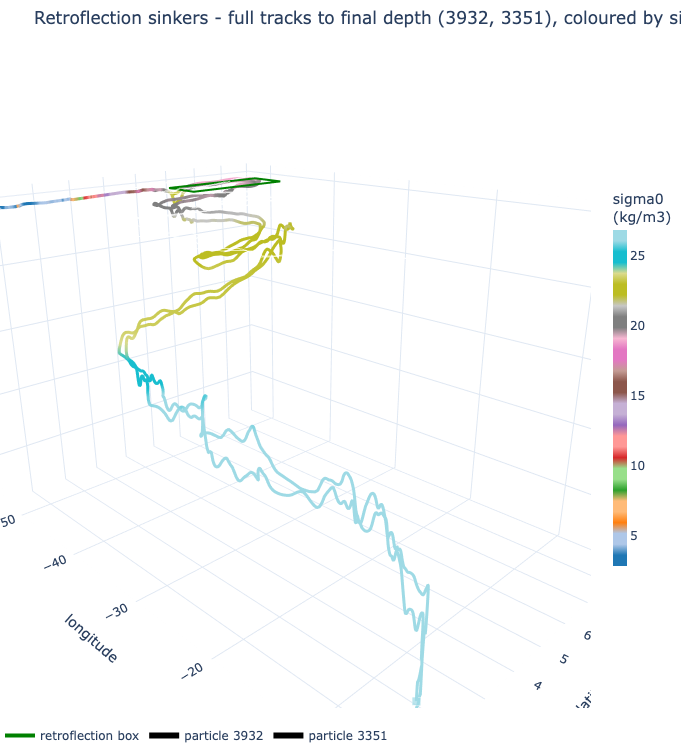

In [14]:
import plotly.graph_objects as go
import matplotlib as mpl

# The GIF runs on a 2-day grid; for a still figure we can afford the native
# observation frequency (~5 per day), so the descent is smooth rather than
# faceted. Same pair, same sigma0 recipe, full track to its final depth.
HTML_OUT = f"retroflection_sink_3d_{int(PAIR_MIN_DEPTH)}m.html"
MARKER_SYMBOLS = ["circle", "square"]


def _native(name, locs):
    ds = xr.open_zarr(store_paths[name])
    lat, lon, z = ds.lat.values[locs], ds.lon.values[locs], ds.z.values[locs]
    sal, temp = ds.sal.values[locs], ds.temp.values[locs]
    t = ds.time.values[locs]
    rel = (t - t[:, :1]) / np.timedelta64(1, "D")
    p  = gsw.p_from_z(-z, lat)
    SA = gsw.SA_from_SP(sal, p, lon, lat)
    CT = gsw.CT_from_pt(SA, temp)
    s0 = gsw.sigma0(SA, CT)
    out = []
    for k in range(len(locs)):
        ok = (~np.isnan(lon[k]) & ~np.isnat(t[k]) & np.isfinite(s0[k]))
        out.append(dict(local=int(locs[k]), lat=lat[k][ok], lon=lon[k][ok],
                        z=z[k][ok], sigma0=s0[k][ok], day=rel[k][ok]))
    return out


# duo comes from the cell above (same store here, but group properly anyway)
by_store = {}
for t in duo:
    by_store.setdefault(t["store"], []).append(t["local"])
nat = [p for name, locs in by_store.items() for p in _native(name, locs)]


def _mpl_scale(name, n=32):
    """matplotlib colormap -> plotly colorscale, so this follows SIGMA_CMAP."""
    cm = mpl.colormaps[name]
    return [[i / (n - 1), "rgb({:d},{:d},{:d})".format(*(int(255 * v) for v in c[:3]))]
            for i, c in enumerate(cm(np.linspace(0, 1, n)))]


SCALE = _mpl_scale(SIGMA_CMAP)
smin = float(min(np.nanmin(p["sigma0"]) for p in nat))
smax = float(max(np.nanmax(p["sigma0"]) for p in nat))

fig = go.Figure()

# retroflection box on the surface plane
fig.add_trace(go.Scatter3d(
    x=[RETRO_LON[0], RETRO_LON[1], RETRO_LON[1], RETRO_LON[0], RETRO_LON[0]],
    y=[RETRO_LAT[0], RETRO_LAT[0], RETRO_LAT[1], RETRO_LAT[1], RETRO_LAT[0]],
    z=[0, 0, 0, 0, 0], mode="lines", line=dict(color="green", width=4),
    name="retroflection box", hoverinfo="skip"))

for i, p in enumerate(nat):
    hover = ("day %{customdata[0]:.1f}<br>depth %{z:.1f} m"
             "<br>sigma0 %{customdata[1]:.2f} kg/m3"
             "<br>%{y:.2f}N  %{x:.2f}E<extra></extra>")
    cdata = np.column_stack([p["day"], p["sigma0"]])
    # the track, coloured along its length by sigma0
    fig.add_trace(go.Scatter3d(
        x=p["lon"], y=p["lat"], z=p["z"], mode="lines",
        line=dict(color=p["sigma0"], colorscale=SCALE, cmin=smin, cmax=smax,
                  width=6),
        name=f"particle {p['local']}", customdata=cdata, hovertemplate=hover,
        showlegend=True))
    # surface shadow = horizontal path only
    fig.add_trace(go.Scatter3d(
        x=p["lon"], y=p["lat"], z=np.zeros_like(p["z"]), mode="lines",
        line=dict(color="rgba(150,150,150,0.55)", width=2),
        name=f"{p['local']} shadow", hoverinfo="skip", showlegend=False))
    # start and final position
    fig.add_trace(go.Scatter3d(
        x=[p["lon"][0], p["lon"][-1]], y=[p["lat"][0], p["lat"][-1]],
        z=[p["z"][0], p["z"][-1]], mode="markers",
        marker=dict(size=[5, 9], symbol=MARKER_SYMBOLS[i % 2],
                    color=[p["sigma0"][0], p["sigma0"][-1]],
                    colorscale=SCALE, cmin=smin, cmax=smax,
                    line=dict(color="white", width=1),
                    colorbar=dict(title="sigma0<br>(kg/m3)", thickness=14,
                                  len=.6) if i == 0 else None),
        name=f"{p['local']} start/end", hoverinfo="skip", showlegend=False))

fig.update_layout(
    title=(f"Retroflection sinkers - full tracks to final depth "
           f"({', '.join(str(p['local']) for p in nat)}), coloured by sigma0"),
    scene=dict(
        xaxis_title="longitude", yaxis_title="latitude", zaxis_title="depth (m)",
        zaxis=dict(autorange="reversed"),          # depth increases downward
        aspectmode="manual", aspectratio=dict(x=1.6, y=1.1, z=1.0),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))),
    template="plotly_white", height=750,
    margin=dict(l=0, r=0, t=48, b=0),
    legend=dict(orientation="h", y=-0.02))

fig.write_html(HTML_OUT, include_plotlyjs=True)   # self-contained, openable alone
print(f"wrote {HTML_OUT}  ({os.path.getsize(HTML_OUT)/1e6:.1f} MB)")
for p in nat:
    print(f"  particle {p['local']}: {len(p['z']):4d} obs | "
          f"final depth {p['z'][-1]:6.1f} m | max {np.nanmax(p['z']):6.1f} m | "
          f"sigma0 {p['sigma0'][0]:.2f} -> {p['sigma0'][-1]:.2f}")
fig.show()
